In [118]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-testing-master.csv
/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-training-master.csv


# **Import Libraries**

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# **Load Dataset**

In [120]:
df = pd.read_csv('/kaggle/input/datasets/muhammadshahidazeem/customer-churn-dataset/customer_churn_dataset-training-master.csv')

In [121]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


# **Data Understanding**

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [123]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [124]:
df.duplicated().sum()

np.int64(0)

In [125]:
df.shape

(440833, 12)

In [126]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [127]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [128]:
df.dtypes

CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [129]:
df.value_counts('Subscription Type')

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [130]:
df.value_counts('Contract Length')

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

# **Exploratory Data Analysis (EDA)**

<Axes: >

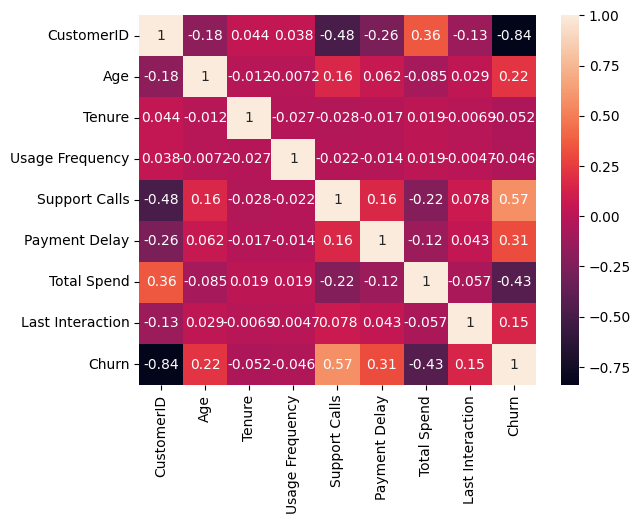

In [131]:
# num_col = df[['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn ']]
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [132]:
df.value_counts('Churn')

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

<Axes: xlabel='Tenure'>

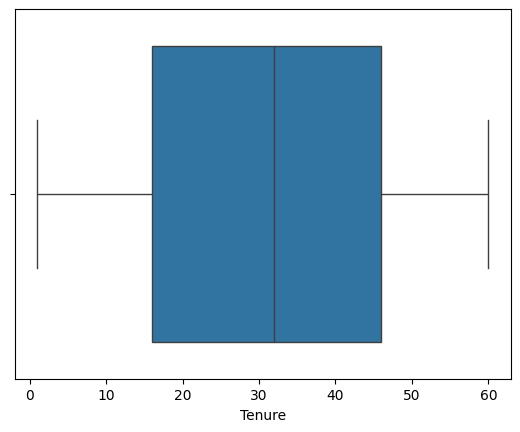

In [133]:
sns.boxplot(data=df, x='Tenure')

<Axes: xlabel='Age'>

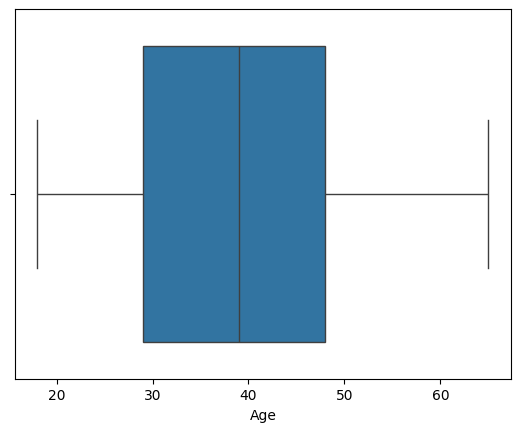

In [134]:
sns.boxplot(data=df, x='Age')

<Axes: xlabel='Support Calls'>

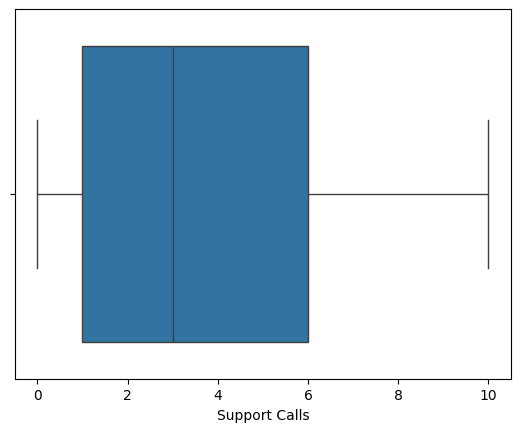

In [135]:
sns.boxplot(data=df, x='Support Calls')

In [136]:
df.sample(10)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
243455,250181.0,63.0,Female,27.0,24.0,2.0,6.0,Standard,Quarterly,675.95,29.0,1.0
273063,280177.0,50.0,Male,38.0,25.0,4.0,6.0,Premium,Quarterly,849.04,6.0,0.0
109276,112662.0,43.0,Male,15.0,4.0,1.0,20.0,Basic,Monthly,980.00,1.0,1.0
319075,326190.0,19.0,Male,50.0,25.0,0.0,7.0,Standard,Quarterly,657.64,11.0,0.0
213285,218668.0,34.0,Male,11.0,13.0,0.0,4.0,Premium,Monthly,693.00,16.0,1.0
360410,367525.0,19.0,Male,34.0,4.0,1.0,8.0,Premium,Quarterly,909.99,30.0,0.0
405673,412788.0,43.0,Female,59.0,29.0,2.0,13.0,Basic,Quarterly,869.31,5.0,0.0
156238,161049.0,46.0,Female,18.0,17.0,8.0,23.0,Basic,Quarterly,372.00,8.0,1.0
311828,318943.0,41.0,Male,3.0,29.0,1.0,11.0,Standard,Annual,514.97,20.0,0.0
103421,106536.0,34.0,Female,48.0,25.0,2.0,7.0,Premium,Annual,762.00,30.0,1.0


# **Data Cleaning**

In [137]:
df.drop('CustomerID',axis=1, inplace=True)

In [138]:
# df['Age'].isna().sum()
# np.isinf(df['Age']).sum()
print(df['Age'].unique())


[30. 65. 55. 58. 23. 51. 39. 64. 29. 52. 22. 48. 24. 49. 19. 47. 42. 57.
 27. 59. 21. 60. 35. 18. 56. 20. 63. 25. 28. 32. 38. 37. 31. 53. 41. 33.
 26. 36. 44. 34. 61. 40. 45. 46. 54. 43. 50. 62. nan]


In [139]:
print(df['Tenure'].unique())


[39. 49. 14. 38. 32. 33. 37. 12.  3. 18. 21. 41. 35.  4. 56. 44. 15. 55.
 43. 52. 26.  2. 29. 59. 40. 51. 53. 24. 30.  6. 28. 17. 60.  7. 34. 10.
  5. 45. 54. 58. 25. 13. 47. 31. 22. 19. 23.  1.  8. 46. 16. 50. 48. 11.
 42. 27.  9. 20. 57. 36. nan]


In [140]:
print(df['Usage Frequency'].unique())


[14.  1.  4. 21. 20. 25. 12.  8.  5.  9.  6. 17. 23. 13. 16. 27.  2. 28.
 29. 15. 24.  3. 22. 26. 30.  7. 11. 18. 19. 10. nan]


In [141]:
print(df['Gender'].unique())


['Female' 'Male' nan]


In [142]:
df = df.replace([np.inf, -np.inf], np.nan)

# Step 2: Handle NaN values across all numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns

# Example: fill with median of each column
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))

# Step 3: Convert to integer safely
df[num_cols] = df[num_cols].astype(int)

In [143]:
df['Gender'] = df['Gender'].fillna('Unknown')
df['Contract Length'] = df['Contract Length'].fillna('Unknown')


In [144]:
df['Subscription Type'] = df['Subscription Type'].fillna('Unknown')

In [145]:
print(df.isna().sum())          # count NaNs per column
print(np.isinf(df.select_dtypes(include=[np.number])).sum())


Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64
Age                 0
Tenure              0
Usage Frequency     0
Support Calls       0
Payment Delay       0
Total Spend         0
Last Interaction    0
Churn               0
dtype: int64


In [146]:
print(df.isna().sum())


Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [147]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [148]:
X_one_encoded = pd.get_dummies(X, columns=['Gender', 'Subscription Type', 'Contract Length'], drop_first=True)

In [149]:
X_one_encoded

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Gender_Unknown,Subscription Type_Premium,Subscription Type_Standard,Subscription Type_Unknown,Contract Length_Monthly,Contract Length_Quarterly,Contract Length_Unknown
0,30,39,14,5,18,932,17,False,False,False,True,False,False,False,False
1,65,49,1,10,8,557,6,False,False,False,False,False,True,False,False
2,55,14,4,6,18,185,3,False,False,False,False,False,False,True,False
3,58,38,21,7,7,396,29,True,False,False,True,False,True,False,False
4,23,32,20,5,8,617,20,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42,54,15,1,3,716,8,True,False,True,False,False,False,False,False
440829,25,8,13,1,20,745,2,False,False,True,False,False,False,False,False
440830,26,35,27,1,5,977,9,True,False,False,True,False,False,True,False
440831,28,55,14,2,0,602,2,True,False,False,True,False,False,True,False


In [150]:
X_one_encoded = X_one_encoded.astype(int)

In [151]:
X_one_encoded

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Gender_Unknown,Subscription Type_Premium,Subscription Type_Standard,Subscription Type_Unknown,Contract Length_Monthly,Contract Length_Quarterly,Contract Length_Unknown
0,30,39,14,5,18,932,17,0,0,0,1,0,0,0,0
1,65,49,1,10,8,557,6,0,0,0,0,0,1,0,0
2,55,14,4,6,18,185,3,0,0,0,0,0,0,1,0
3,58,38,21,7,7,396,29,1,0,0,1,0,1,0,0
4,23,32,20,5,8,617,20,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42,54,15,1,3,716,8,1,0,1,0,0,0,0,0
440829,25,8,13,1,20,745,2,0,0,1,0,0,0,0,0
440830,26,35,27,1,5,977,9,1,0,0,1,0,0,1,0
440831,28,55,14,2,0,602,2,1,0,0,1,0,0,1,0


 # **Feature Scaling**

In [152]:
numeric_col = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']
scaler = StandardScaler()
X_one_encoded[numeric_col] = scaler.fit_transform(X_one_encoded[numeric_col]) 

In [153]:
X_one_encoded

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Gender_Unknown,Subscription Type_Premium,Subscription Type_Standard,Subscription Type_Unknown,Contract Length_Monthly,Contract Length_Quarterly,Contract Length_Unknown
0,-0.753327,0.448760,-0.210511,0.454550,0.609621,1.248972,0.293052,0,0,0,1,0,0,0,0
1,2.059648,1.028279,-1.724565,2.083103,-0.601319,-0.308841,-0.986585,0,0,0,0,0,1,0,0
2,1.255941,-1.000038,-1.375168,0.780261,0.609621,-1.854191,-1.335576,0,0,0,0,0,0,1,0
3,1.497053,0.390808,0.604749,1.105971,-0.722413,-0.977662,1.689020,1,0,0,1,0,1,0,0
4,-1.315922,0.043097,0.488283,0.454550,-0.601319,-0.059591,0.642044,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,0.211122,1.318039,-0.094045,-0.848292,-1.206789,0.351672,-0.753923,1,0,1,0,0,0,0,0
440829,-1.155181,-1.347749,-0.326977,-0.848292,0.851810,0.472142,-1.451907,0,0,1,0,0,0,0,0
440830,-1.074810,0.216952,1.303543,-0.848292,-0.964601,1.435909,-0.637593,1,0,0,1,0,0,1,0
440831,-0.914069,1.375990,-0.210511,-0.522581,-1.570072,-0.121903,-1.451907,1,0,0,1,0,0,1,0


# **Train-Test Split**

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encoded, y, random_state=42, test_size=0.25)

In [155]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [156]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 0, ..., 1, 1, 0])

In [157]:
y_test

69437     1
224323    1
22398     1
283708    0
167619    1
         ..
248871    1
122621    1
180751    1
81084     1
390016    0
Name: Churn, Length: 110209, dtype: int64

# **Model Evaluation**

In [158]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8958433521763195
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     47687
           1       0.93      0.89      0.91     62522

    accuracy                           0.90    110209
   macro avg       0.89      0.90      0.89    110209
weighted avg       0.90      0.90      0.90    110209



# **Using GridSearchCV to increase acuracy and recall** 

## 🔧 Hyperparameter Tuning (GridSearchCV)

In this section, we optimize the Logistic Regression model by tuning hyperparameters such as C and penalty using GridSearchCV.

In [159]:
# Define parameters
param_grid = {
    'C' : [0.01,0.1,0.5, 1,10,100],
    'penalty' : ['l2'],
    'solver' : ['lbfgs']
}

In [160]:
# Create Grid Search object
grid = GridSearchCV(
    estimator = LogisticRegression(max_iter=1000), 
    param_grid = param_grid,
    cv = 6,
    scoring = 'f1', 
    verbose = 2,
    n_jobs = -1
)

In [161]:
# Train Grid Search 
grid.fit(X_train, y_train)

Fitting 6 folds for each of 6 candidates, totalling 36 fits


GridSearchCV(cv=6, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 0.5, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='f1', verbose=2)

In [162]:
# Get Best Model
best_model = grid.best_estimator_

In [163]:
# Best parameter
print(grid.best_params_)

{'C': 0.5, 'penalty': 'l2', 'solver': 'lbfgs'}


In [164]:
y_pred1 = best_model.predict(X_test)
y_pred1

array([1, 1, 0, ..., 1, 1, 0])

In [165]:
y_test

69437     1
224323    1
22398     1
283708    0
167619    1
         ..
248871    1
122621    1
180751    1
81084     1
390016    0
Name: Churn, Length: 110209, dtype: int64

In [166]:
print("Train Score:", best_model.score(X_train, y_train))
print("Test Score:", best_model.score(X_test, y_test))

Train Score: 0.8951074332171893
Test Score: 0.8958524258454391


In [167]:
print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))


Accuracy: 0.8958524258454391
              precision    recall  f1-score   support

           0       0.86      0.91      0.88     47687
           1       0.93      0.89      0.91     62522

    accuracy                           0.90    110209
   macro avg       0.89      0.90      0.89    110209
weighted avg       0.90      0.90      0.90    110209



# **Use of Joblib**

In [168]:
import joblib

joblib.dump(best_model, 'Churn_model.pkl')

['Churn_model.pkl']

In [169]:
model1 = joblib.load('Churn_model.pkl')

In [170]:
df.sample()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
219139,38,Male,43,29,2,6,Standard,Monthly,966,23,1


In [171]:
X_one_encoded.sample()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Gender_Unknown,Subscription Type_Premium,Subscription Type_Standard,Subscription Type_Unknown,Contract Length_Monthly,Contract Length_Quarterly,Contract Length_Unknown
239468,0.130751,-0.246663,0.721214,-1.174002,0.609621,1.323747,-0.17227,0,0,0,0,0,1,0,0


In [174]:
new_data = pd.DataFrame([[21,15,9,0,12,700,9,1,0,1,0,0,0,1,0]], columns = X_one_encoded.columns)
prediction = model1.predict(new_data)
print(prediction)

[0]
